# 02 - Multivariate Hawkes and Connectivity

With several event streams, a **multivariate Hawkes process** lets events in
one dimension excite others. For dimension $m$,

$$\lambda_m(t) = \mu_m + \sum_{k} \sum_{t_i^k < t} \varphi_{mk}(t - t_i^k),$$

where $\varphi_{mk}$ is the kernel from source $k$ to target $m$. The matrix
of kernel norms $W_{mk} = \int \varphi_{mk}$ is the **connectivity matrix**:
a directed, weighted graph of who excites whom. This notebook recovers a known
connectivity structure and contrasts it with naive independent fits.

*Builds on 01; see it first for the univariate basics.*

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import intensify as it

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.titlesize": 13})

rng = np.random.default_rng(0)
print(f"intensify {it.__version__}")

intensify 0.3.3


## 1. Simulate a coupled 3-node system

We wire an asymmetric network: node 0 strongly drives node 1, node 1 weakly
feeds back, node 2 is largely independent. The kernel matrix is a list of
rows, `kernel[m][k]` = kernel from source `k` to target `m`.

In [2]:
N = 3
labels = ["node 0", "node 1", "node 2"]
T = 2000.0

def K(a):
    return it.ExponentialKernel(alpha=a, beta=1.0)

EPS = 1e-6  # ExponentialKernel needs alpha > 0; use a negligible value for "no link"
#                  source: 0       1        2
kernel_matrix = [[K(0.30), K(EPS), K(EPS)],   # target 0
                 [K(0.45), K(0.20), K(EPS)],   # target 1  (0 -> 1 strong)
                 [K(EPS),  K(EPS), K(0.25)]]   # target 2  (isolated)

sim_model = it.MultivariateHawkes(n_dims=N, mu=[0.20, 0.10, 0.20], kernel=kernel_matrix)
events = sim_model.simulate(T=T, seed=11)
for i, lbl in enumerate(labels):
    ev = np.asarray(events[i])
    print(f"{lbl}: {len(ev):4d} events ({len(ev)/T:.3f}/s)")

node 0:  577 events (0.288/s)
node 1:  578 events (0.289/s)
node 2:  534 events (0.267/s)


## 2. Raster of the three streams

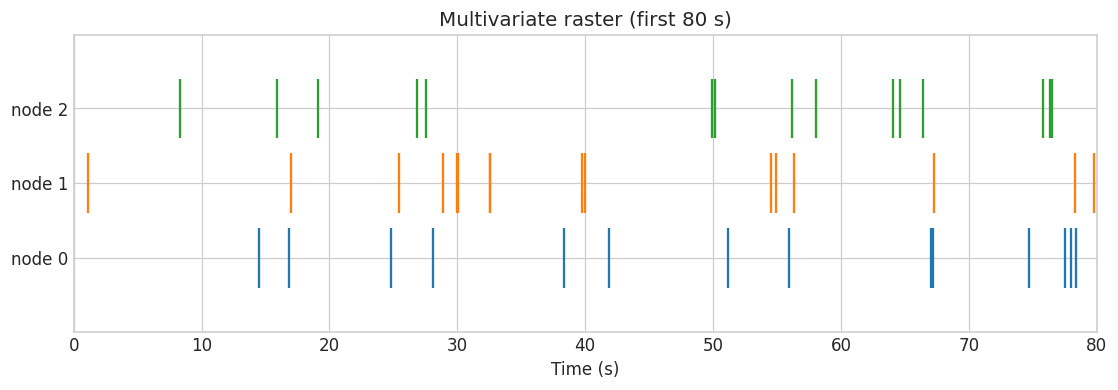

In [3]:
win = (0.0, 80.0)
fig, ax = plt.subplots(figsize=(12, 3.5))
for i, lbl in enumerate(labels):
    ev = np.asarray(events[i])
    ev = ev[(ev >= win[0]) & (ev <= win[1])]
    ax.eventplot(ev, lineoffsets=i, linelengths=0.8, color=f"C{i}")
ax.set_yticks(range(N)); ax.set_yticklabels(labels)
ax.set_xlim(*win); ax.set_xlabel("Time (s)")
ax.set_title("Multivariate raster (first 80 s)")
plt.show()

## 3. Fit and recover the connectivity matrix

A scalar `mu` and a single `kernel` give a shared initial guess for every
dimension and pair; the optimiser estimates all $N$ baselines and $N^2$ kernels.

In [4]:
fit = it.MultivariateHawkes(n_dims=N, mu=0.15, kernel=it.ExponentialKernel(alpha=0.1, beta=1.0))
result = fit.fit(events, T=T, method="mle")
print(result.summary())

W = result.connectivity_matrix()
print("\nfitted connectivity W[target, source]:")
print(np.array2string(W, precision=3, suppress_small=True))

FitResult:
  Log-likelihood: -3549.4677
  AIC: 7106.9353
  BIC: 7128.6629
  Parameters:
    mu: array shape (3,)
    kernel_matrix: [[ExponentialKernel(alpha=0.2923936136402854, beta=0.8961500257096324), ExponentialKernel(alpha=0.04140440312711881, beta=0.9629841147773606), ExponentialKernel(alpha=1e-08, beta=0.9955232694511108)], [ExponentialKernel(alpha=0.4363164968465544, beta=0.8184955507360251), ExponentialKernel(alpha=0.24319209274785292, beta=1.4147529012869058), ExponentialKernel(alpha=0.004176938318993251, beta=1.0080315690383088)], [ExponentialKernel(alpha=0.010088282286941551, beta=0.9985987323937335), ExponentialKernel(alpha=0.019916591450568337, beta=1.0496517954238542), ExponentialKernel(alpha=0.30736892781132347, beta=0.7720825231539908)]]
  Standard errors:
    mu_0: 0.0149
    mu_1: 0.0112
    mu_2: 0.0175
    alpha_0_0: 0.0484
    beta_0_0: 0.2422
    alpha_0_1: 0.0164
    beta_0_1: 0.0000
    alpha_0_2: 0.0000
    beta_0_2: 0.0000
    alpha_1_0: 0.0472
    beta_1_0: 

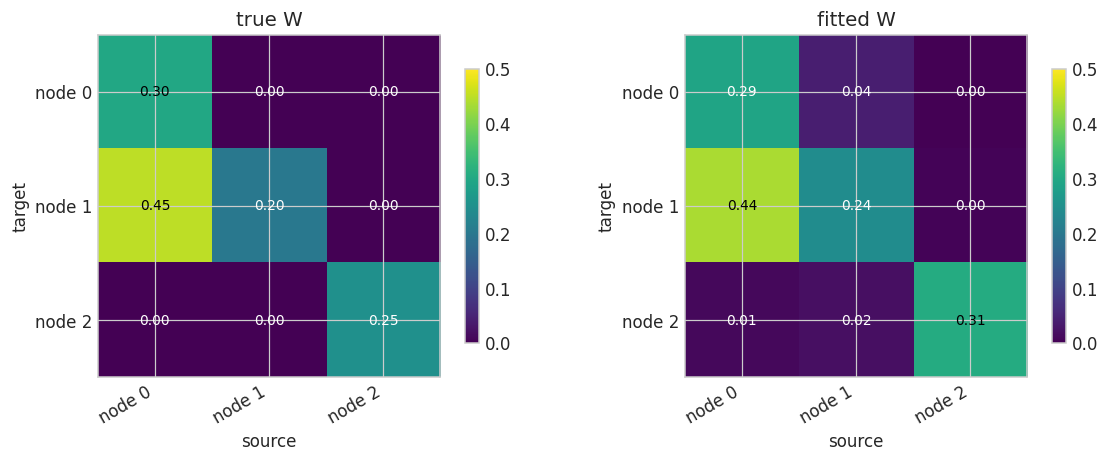

In [5]:
W_true = np.array([[0.30, 0.00, 0.00],
                   [0.45, 0.20, 0.00],
                   [0.00, 0.00, 0.25]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, mat, title in [(axes[0], W_true, "true"), (axes[1], W, "fitted")]:
    im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=0.5)
    ax.set_xticks(range(N)); ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticks(range(N)); ax.set_yticklabels(labels)
    ax.set_xlabel("source"); ax.set_ylabel("target"); ax.set_title(f"{title} W")
    for m in range(N):
        for k in range(N):
            ax.text(k, m, f"{mat[m,k]:.2f}", ha="center", va="center",
                    color="w" if mat[m, k] < 0.3 else "k", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); plt.show()

## 4. Connectivity as a directed graph

`plot_connectivity` renders $W$ as a network; arrow width encodes excitation
strength.

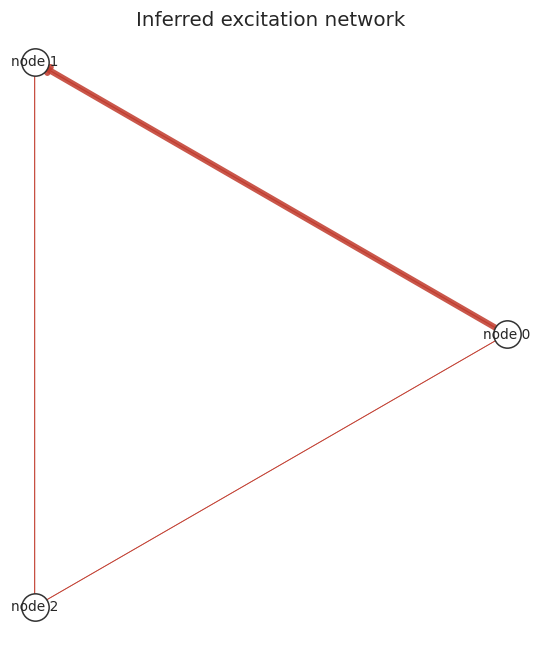

In [6]:
it.plot_connectivity(W, labels=labels)
plt.title("Inferred excitation network")
plt.show()

## 5. Which links are real?

`significant_connections` flags the entries distinguishable from zero, so you
can prune spurious couplings before interpreting the graph.

In [7]:
sig = result.significant_connections(significance_level=0.05)
print("significant links (target <- source):")
for m in range(N):
    for k in range(N):
        if sig[m, k]:
            print(f"  {labels[m]} <- {labels[k]}   (W = {W[m,k]:.3f})")

significant links (target <- source):
  node 0 <- node 0   (W = 0.292)
  node 0 <- node 1   (W = 0.041)
  node 1 <- node 0   (W = 0.436)
  node 1 <- node 1   (W = 0.243)
  node 1 <- node 2   (W = 0.004)
  node 2 <- node 2   (W = 0.307)


## 6. Why joint estimation matters

Fitting each stream as an *independent* univariate Hawkes folds cross-excitation
into the baseline and self-term, inflating apparent self-excitation and losing
the network entirely. Compare the diagonal of the joint fit with the
independent self-estimates.

In [8]:
print(f"{'node':<10}{'joint self':>12}{'independent':>14}")
for i, lbl in enumerate(labels):
    uni = it.UnivariateHawkes(mu=0.15, kernel=it.ExponentialKernel(alpha=0.1, beta=1.0))
    uni_br = uni.fit(np.asarray(events[i]), T=T, method="mle").branching_ratio_
    print(f"{lbl:<10}{W[i, i]:>12.3f}{uni_br:>14.3f}")
print("\nIndependent fits overstate self-excitation for the driven node (node 1).")

node        joint self   independent
node 0           0.292         0.323
node 1           0.243         0.382
node 2           0.307         0.304

Independent fits overstate self-excitation for the driven node (node 1).


## 7. Stationarity: the spectral radius

A multivariate Hawkes process is stationary when the **spectral radius** of
$W$ (its largest-magnitude eigenvalue) is below 1 -- the multivariate analogue
of $\alpha < 1$.

In [9]:
rho = np.max(np.abs(np.linalg.eigvals(W)))
print(f"spectral radius of W = {rho:.3f}  ->  {'stationary' if rho < 1 else 'EXPLOSIVE'}")

spectral radius of W = 0.405  ->  stationary


## 8. How fitting scales

The recursive exponential likelihood is $O(N_{\text{events}})$ per dimension,
so even long catalogues fit quickly thanks to the Rust core.

In [10]:
import time
for Tb in [500.0, 1000.0, 2000.0]:
    ev = sim_model.simulate(T=Tb, seed=99)
    n = sum(len(np.asarray(e)) for e in ev)
    f = it.MultivariateHawkes(n_dims=N, mu=0.15, kernel=it.ExponentialKernel(alpha=0.1, beta=1.0))
    t0 = time.perf_counter(); f.fit(ev, T=Tb, method="mle"); dt = time.perf_counter() - t0
    print(f"T={Tb:6.0f}s  {n:5d} events  fit in {dt:5.2f}s")

T=   500s    377 events  fit in  0.03s
T=  1000s    804 events  fit in  0.05s
T=  2000s   1668 events  fit in  0.10s


/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/inference/mle.py:699: UserWarning: Only 377 events for 21 free parameters (M=3). MLE estimates may be unreliable.
  warnings.warn(


---
### Try it yourself
* Add a feedback link (`node 2 <- node 1`) and confirm the fit recovers it.
* Push the strongest link toward criticality and watch the spectral radius.
* Use a per-pair `ExponentialKernel` matrix with different `beta`s to model
  direction-specific timescales.

### Next steps
* **03_marked_and_online** -- event marks and streaming estimation.
* User guide: [inference](../docs/user_guide/inference.md).